In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import requests
import json

#"How did Bank of Canada rate hikes between 2022 and 2024 affect housing affordability across Canadian cities?"

# grab rates data from bank of canada 
url= "https://www.bankofcanada.ca/valet/lists/series/json"
response= requests.get(url)
data= response.json()

print(data.keys())

dict_keys(['terms', 'series'])


In [3]:
print(type(data['series']))

<class 'dict'>


In [4]:
# commented out since too many keys that causes clutter
#print(list(data['series'].keys()))

In [5]:
# look for keys with mortgage in them to find mortgage rates
for key, value in data['series'].items():
    if 'mortgage' in str(value).lower():
        print (key, value.get('label'))

# What we are interested in
# FVI_MTG_RATE_5Y_FIX 5-year fixed interest rate for a high-ratio mortgage
# FVI_MTG_RATE_5Y_VAR 5-year variable interest rate for a high-ratio mortgage
# FVI_MEDIAN_MDSR_ALL        Median mortgage debt service ratio
# FVI_MEDIAN_LTI_MTG_ALL     Median loan-to-income ratio
# FVI_LOANS_ARR_MTG          Mortgages in arrears

# Note: There are also similar variables such as following:

# FSR_2022_C1A_S1 5-year fixed mortgage rate
# FSR_2022_C1A_S2 5-year variable mortgage rate

# "hihgh-ratio" mortgages are mortgages where the down payment is less than 20% (usually first-time buyers), which is more appropiate
# for our context. FVI series are also continously tracked and updated regularly

ATOM_V41693242 CPIX, percentage change year-over-year (unadjusted)
BMTBTMCS.DALL Bank, trust and mortgage company securities
BROKER_AVERAGE_5YR_VRM Estimated variable mortgage rate 
CES_C14A_MISS_DEBT_P Probability of missing a debt payment, 25-54
CES_C14A_MISS_DEBT_S Probability of missing a debt payment, 55+
CES_C14A_MISS_DEBT_Y Probability of missing a debt payment, 18-24
CES_C14B_MISS_DEBT_B Probability of missing a debt payment, university degree or higher
CES_C14B_MISS_DEBT_C Probability of missing a debt payment, some college
CES_C14B_MISS_DEBT_L Probability of missing a debt payment, high school or lower
CES_C14C_MISS_DEBT_H Probability of missing a debt payment, over 100K
CES_C14C_MISS_DEBT_L Probability of missing a debt payment, under 40K
CES_C14C_MISS_DEBT_M Probability of missing a debt payment, 40K to 100K
CES_C14D_MISS_DEBT_H Probability of missing a debt payment, high numeracy
CES_C14D_MISS_DEBT_L Probability of missing a debt payment, low numeracy
CES_C14E_MISS_DEBT_AB

In [6]:
# same concept for overnight rate
for key, value in data['series'].items():
    if 'overnight' in str(value).lower():
        print(key, value.get('label'))

# What we are interested in
# STATIC_ATABLE_V39079 Overnight rate target (end of month)

# Note:There's an entry as follow:

# V39079 Overnight rate

# V39079 is calculated daily and changes weekly in the fastest scenario. Since we want to have everything on monthly basis we use STATIC instead

AVG.INTWO Canadian Overnight Repo Rate Average (CORRA) (%)
CBC20210 V39079
CL.CDN.MOST.1DL V39050
ORR_KEY ORR KEY
SAN_FONT20250113_C1_S1 Differential for the end of 2025 implied by overnight index swap
SAN_FONT20250113_C3_S3 Overnight index swap rate
SAN_FONT20250113_C4_S1 Bank of Canada (BoC) overnight rate (left scale)
SAN_GIGN20221214_C4B_S4 Overnight Index Swap
SAN_GIGN20221214_C4_S4 Overnight Index Swap
SAN_LEBM180118_CHART2F_A_OR OR
SAN_LEBM180118_CHART2F_B_OR_LOWER OR_Lower
SAN_LEBM180118_CHART2F_C_OR_UPPER OR_Upper
SAN_MARU20240305_C1_S1 Net outstanding repo (dealer to all clients; reverse repo less repo; overnight, regular and term) (left scale)
SAN_MARU20240305_C2_S1 Net outstanding repo (dealer to all clients excluding hedge funds; reverse repo less repo; overnight, regular and term) (left scale)
SAN_MARU20240305_C2_S2 Net outstanding repo (dealer to hedge funds; reverse repo less repo; overnight, regular and term) (left scale)
SAN_MARU20240305_C6_S1 Top two overnight genera

In [7]:
# same concept for prime rate
for key, value in data['series'].items():
    if 'prime' in str(value).lower():
        print(key, value.get('label'))

# What we are interested in
# V80691311 Prime rate

# Note: Prime rate is almost always 2.2% percentage points above the policy rate, but it's good to incorporate

CP.CDN.30D.OPER V39072
CP.CDN.60D.OPER V39073
CP.CDN.90D.OPER V39074
FSHUB_20210317_C9_S1 Below prime
FSHUB_20210317_C9_S2 Prime
FSHUB_20210317_C9_S3 Above prime
V121796 V80691311
V121809 V80691315
V121812 V80691317
V121820 V121820
V122148 V122148
V122495 V122495
V122509 V122509
V80691311 Prime rate
WM_SAN_KOST20190306_C2_PRIMEAGE Prime-age workers
WM_SAN_KOST20190306_C3_PRIMEAGE Prime-age workers
WM_SAN_KOST20190306_C3_PRIMEAGE-PC10YA Prime-age workers - 10 year pre-crisis average
WM_SAN_KOST20190306_C4_PRIMEAGE Prime-age workers


In [8]:
# function to find observation data with respect to the series_id we are interested in and record and append them to a list
def fetch_boc_series (series_id, start_date= "2018-01-01"):
    url= f"https://www.bankofcanada.ca/valet/observations/{series_id}/json"
    params= {"start_date": start_date}
    response= requests.get(url, params=params)
    data= response.json()

    records= []
    for obs in data["observations"]:
        records.append({
            "date": obs["d"],
            "series_id": series_id,
            "value": obs[series_id]["v"]
        }
        )

    return pd.DataFrame(records)

# find the data for respective series_id using the function
policy_rate= fetch_boc_series("STATIC_ATABLE_V39079")
mortgage_5y_fix= fetch_boc_series("FVI_MTG_RATE_5Y_FIX")
mortgage_5y_var= fetch_boc_series("FVI_MTG_RATE_5Y_VAR")
debt_service_ratio = fetch_boc_series("FVI_MEDIAN_MDSR_ALL")
loan_to_income_ratio = fetch_boc_series("FVI_MEDIAN_LTI_MTG_ALL")
mortgage_arrears = fetch_boc_series("FVI_LOANS_ARR_MTG")
prime_rate = fetch_boc_series("V80691311")


# Create the dataframe using the found variables as columns and date as index
df= pd.concat([policy_rate, mortgage_5y_fix, mortgage_5y_var, debt_service_ratio, 
               loan_to_income_ratio, mortgage_arrears, prime_rate]).pivot(index="date", columns="series_id", values="value")

df= df.rename(columns={
    "STATIC_ATABLE_V39079": "policy_rate",
    "FVI_MTG_RATE_5Y_FIX": "mortgage_rate_5yrs_fixed",
    "FVI_MTG_RATE_5Y_VAR": "mortgage_rate_5yrs_variable",
    "FVI_MEDIAN_MDSR_ALL": "debt_service_ratio",
    "FVI_MEDIAN_LTI_MTG_ALL": "loan_to_income_ratio",
    "FVI_LOANS_ARR_MTG": "mortgage_arrears",
    "V80691311": "prime_rate"
    }
    )

print(df.head(40))

series_id  mortgage_arrears loan_to_income_ratio debt_service_ratio  \
date                                                                  
2018-01-01             0.20               280.79              16.90   
2018-01-02              NaN                  NaN                NaN   
2018-01-03              NaN                  NaN                NaN   
2018-01-09              NaN                  NaN                NaN   
2018-01-10              NaN                  NaN                NaN   
2018-01-16              NaN                  NaN                NaN   
2018-01-17              NaN                  NaN                NaN   
2018-01-23              NaN                  NaN                NaN   
2018-01-24              NaN                  NaN                NaN   
2018-01-30              NaN                  NaN                NaN   
2018-01-31              NaN                  NaN                NaN   
2018-02-01              NaN                  NaN                NaN   
2018-0

In [9]:
print(df.dtypes)

# data type is stored as objects and needs to be turned numeric

series_id
mortgage_arrears               object
loan_to_income_ratio           object
debt_service_ratio             object
mortgage_rate_5yrs_fixed       object
mortgage_rate_5yrs_variable    object
policy_rate                    object
prime_rate                     object
dtype: object


In [10]:
# convert to float and if can't be converted to a number return NaN instead of error
df= df.apply(pd.to_numeric, errors= "coerce")
print(df.dtypes)

series_id
mortgage_arrears               float64
loan_to_income_ratio           float64
debt_service_ratio             float64
mortgage_rate_5yrs_fixed       float64
mortgage_rate_5yrs_variable    float64
policy_rate                    float64
prime_rate                     float64
dtype: object


In [11]:
df.to_csv("../data/processed/boc_rates.csv")

In [12]:
print(df[["mortgage_rate_5yrs_fixed", "mortgage_rate_5yrs_variable"]].dropna().head(10))

# dropping the missing values we can see the rates for mortgages are changing on weekly basis, hence why not showing up
# noticing that variable looks more constant that fixed in first 10 enteries, which seems unusual

series_id   mortgage_rate_5yrs_fixed  mortgage_rate_5yrs_variable
date                                                             
2018-01-02                      3.14                         2.50
2018-01-09                      3.14                         2.50
2018-01-16                      3.19                         2.60
2018-01-23                      3.19                         2.55
2018-01-30                      3.19                         2.55
2018-02-06                      3.19                         2.50
2018-02-13                      3.24                         2.50
2018-02-20                      3.24                         2.50
2018-02-27                      3.24                         2.50
2018-03-06                      3.24                         2.50


In [13]:
print(df[["mortgage_rate_5yrs_fixed", "mortgage_rate_5yrs_variable"]].dropna().describe())

# the variable mortgage rate has higher std, which makes sense and removes the initial suspecion

series_id  mortgage_rate_5yrs_fixed  mortgage_rate_5yrs_variable
count                    427.000000                   427.000000
mean                       3.591429                     3.551475
std                        1.111777                     1.647639
min                        1.690000                     1.280000
25%                        2.715000                     2.250000
50%                        3.540000                     2.950000
75%                        4.590000                     5.050000
max                        5.720000                     6.300000


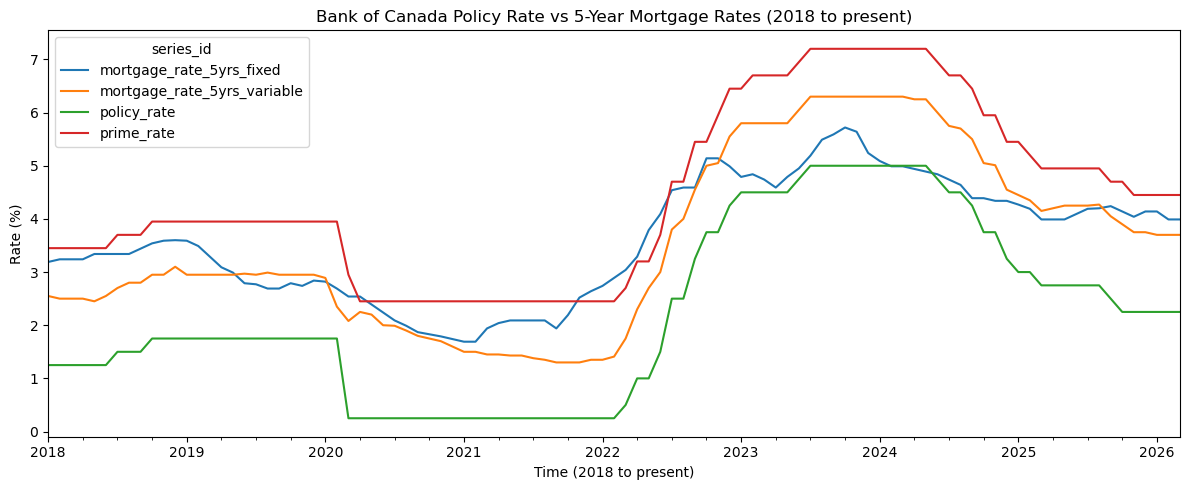

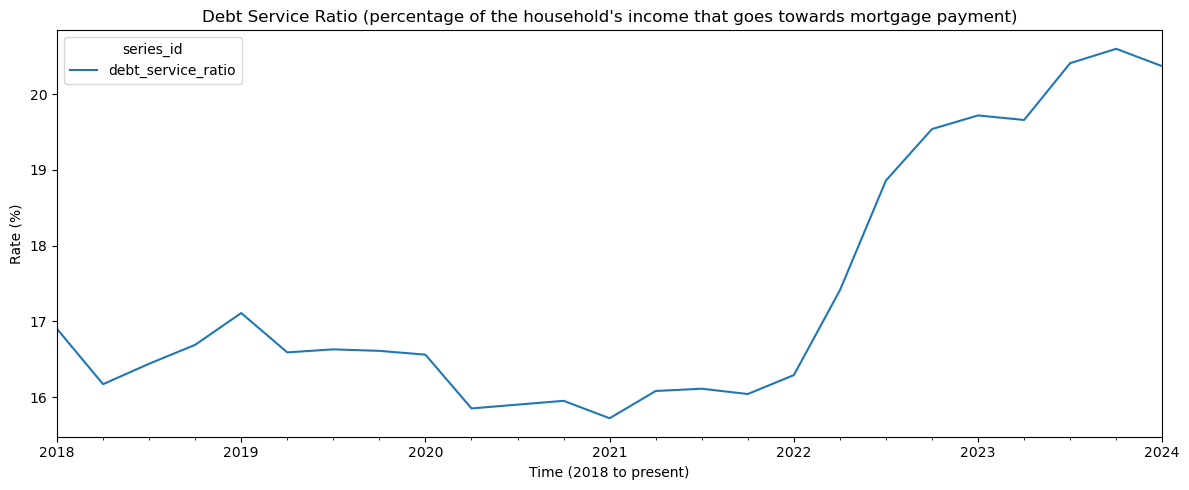

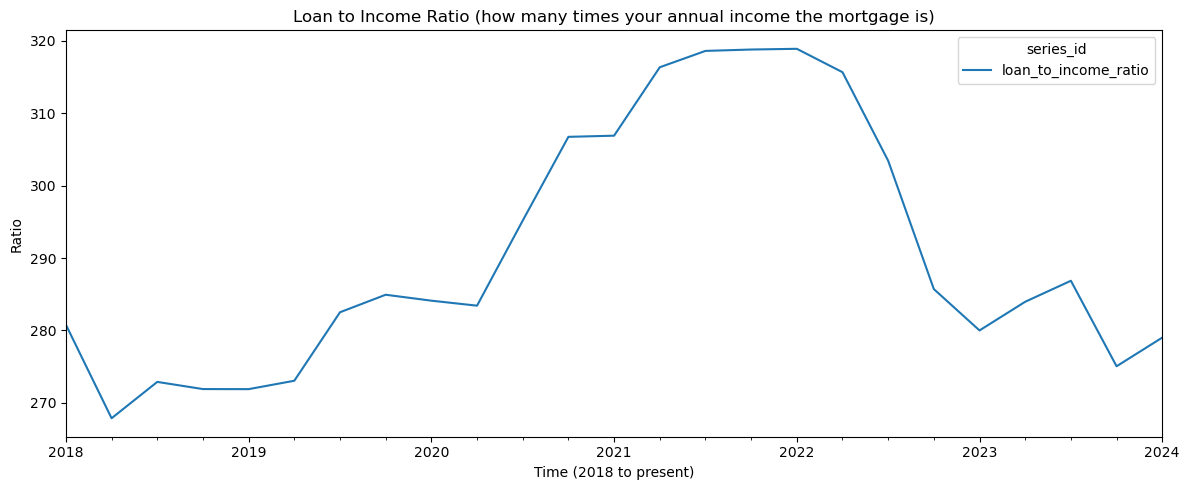

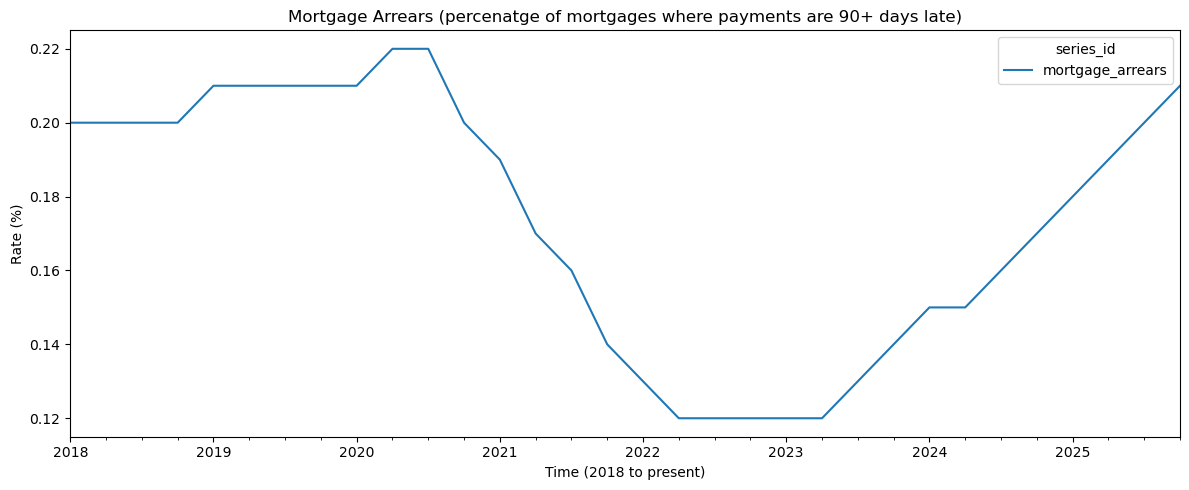

In [14]:

# convert index aka. date rows to datetime format and sample on monthly basis instead to make sure all rates are compared on the same basis
# mortgage rates and prime rate are weekly, policy rate is monthly and ratios and arrears are quarterly

df.index = pd.to_datetime(df.index)
df_monthly = df.resample("ME").last()

df_monthly[["mortgage_rate_5yrs_fixed", "mortgage_rate_5yrs_variable", "policy_rate", "prime_rate"]].dropna().plot(
    figsize=(12, 5),
    title="Bank of Canada Policy Rate vs 5-Year Mortgage Rates (2018 to present)"
)
plt.xlabel("Time (2018 to present)")
plt.ylabel("Rate (%)")
plt.tight_layout()
plt.show()

df_monthly[["debt_service_ratio"]].dropna().plot(
    figsize=(12, 5),
    title="Debt Service Ratio (percentage of the household's income that goes towards mortgage payment)"
)
plt.xlabel("Time (2018 to present)")
plt.ylabel("Rate (%)")
plt.tight_layout()
plt.show()

df_monthly[["loan_to_income_ratio"]].dropna().plot(
    figsize=(12, 5),
    title="Loan to Income Ratio (how many times your annual income the mortgage is)"
)
plt.xlabel("Time (2018 to present)")
plt.ylabel("Ratio")
plt.tight_layout()
plt.show()

df_monthly[["mortgage_arrears"]].dropna().plot(
    figsize=(12, 5),
    title="Mortgage Arrears (percenatge of mortgages where payments are 90+ days late)"
)
plt.xlabel("Time (2018 to present)")
plt.ylabel("Rate (%)")
plt.tight_layout()
plt.show()

In [15]:
df_monthly.to_csv("../data/processed/boc_rates_monthly.csv")

In [16]:
crea = pd.read_excel("../data/raw/Not_Seasonally_Adjusted_(M).xlsx", 
                     sheet_name=['GREATER_TORONTO', 'GREATER_VANCOUVER', 'CALGARY', 'EDMONTON', 'MONTREAL_CMA', 'OTTAWA', 'WINNIPEG', 'HALIFAX_DARTMOUTH'])

crea

{'GREATER_TORONTO':           Date  Composite_HPI  Single_Family_HPI  One_Storey_HPI  \
 0   2005-01-01          100.0              100.0           100.0   
 1   2005-02-01          100.8              100.8           101.4   
 2   2005-03-01          102.1              102.2           103.2   
 3   2005-04-01          102.9              103.2           104.1   
 4   2005-05-01          103.6              103.7           104.8   
 ..         ...            ...                ...             ...   
 249 2025-10-01          303.6              323.4           320.2   
 250 2025-11-01          301.8              321.8           316.2   
 251 2025-12-01          298.9              318.4           311.4   
 252 2026-01-01          296.6              316.7           310.0   
 253 2026-02-01          297.7              318.1           311.8   
 
      Two_Storey_HPI  Townhouse_HPI  Apartment_HPI  Composite_Benchmark  \
 0             100.0          100.0          100.0               315300   
 

In [17]:
print(type(crea))
print(crea.keys())

<class 'dict'>
dict_keys(['GREATER_TORONTO', 'GREATER_VANCOUVER', 'CALGARY', 'EDMONTON', 'MONTREAL_CMA', 'OTTAWA', 'WINNIPEG', 'HALIFAX_DARTMOUTH'])


In [34]:
# a loop to go through each dataframe associated with each city and extract date and composite benchmark and append them as a collection 
# with formating adjustments, including sorting and filtering for years of 2018 and afterwards

collect = []   

for city, df in crea.items():
    temp = df[["Date", "Composite_Benchmark"]].copy()
    temp["City"] = city
    collect.append(temp)
    
crea_monthly= pd.concat(collect).sort_values("Date")
crea_monthly= crea_monthly[["Date","City", "Composite_Benchmark"]]
crea_monthly= crea_monthly.query('Date.dt.year >= 2018').reset_index(drop = True)
print(crea_monthly)

          Date               City  Composite_Benchmark
0   2018-01-01             OTTAWA               378800
1   2018-01-01    GREATER_TORONTO               749600
2   2018-01-01       MONTREAL_CMA               316200
3   2018-01-01  HALIFAX_DARTMOUTH               273300
4   2018-01-01  GREATER_VANCOUVER              1029400
..         ...                ...                  ...
779 2026-02-01            CALGARY               562000
780 2026-02-01  GREATER_VANCOUVER              1100300
781 2026-02-01    GREATER_TORONTO               938800
782 2026-02-01           WINNIPEG               383800
783 2026-02-01  HALIFAX_DARTMOUTH               558600

[784 rows x 3 columns]


In [36]:
crea_monthly.to_csv("../data/processed/crea_monthly_benchmark.csv", index= False)

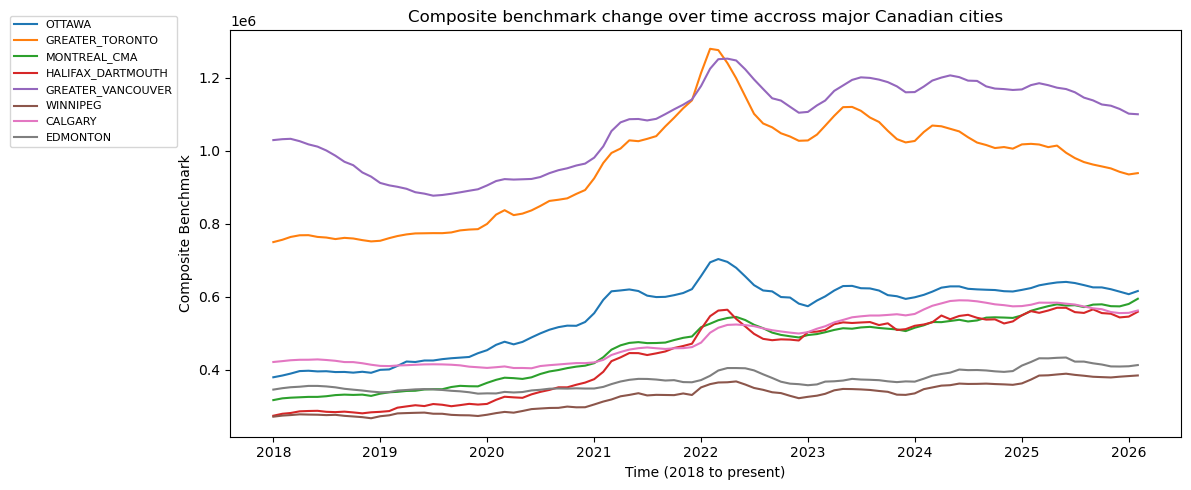

In [21]:
plt.figure(figsize= (12,5))

# loop through each unique city and seperate their data as a df to plot
for city in crea_monthly["City"].unique():
    city_df= crea_monthly[crea_monthly["City"] == city]
    plt.plot(city_df["Date"], city_df["Composite_Benchmark"], label= city)

plt.xlabel("Time (2018 to present)")
plt.ylabel("Composite Benchmark")
plt.title("Composite benchmark change over time accross major Canadian cities")
plt.legend(bbox_to_anchor=(-0.05, 1.05), fontsize= 8)
plt.tight_layout()
plt.show()